In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


In [2]:
#settings
N = 5  # Number of variables
F = 8  # Forcing
start = F * np.ones(N)  # Initial state (equilibrium)
start[0] += 0.01  # Add small perturbation to the first variable
dt = 0.01
subset_size = 200
traj_length = int(1e6)#length of trajectory
noise_level = 0.05
sample_size = int(5000)
slope = 0.1

simulation_t = int(5e3)
def L96(x, t):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 


t = np.arange(0.0, traj_length*dt, dt)



In [3]:
trajectory_clean = scipy.integrate.odeint(L96, start, t)

In [4]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):]

#a random chuck of data
rand_start = np.random.randint(1, len(trajectory)-sample_size)
randpts = torch.tensor(trajectory[rand_start:rand_start+sample_size],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_start+1:rand_start+1+sample_size],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
class W2Loss(torch.autograd.Function):#MAT
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


In [5]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)

N_iters = 10000

net1.train()
loss1 = []
invert_variables = [0,1,2,3,4]
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor

V_field = net1(net1_randpts)
net1_randpts = net1_randpts+dt* V_field
U_net = Ulam(randpts,net1_randpts)

initial_L1 = W2Loss.apply(U_net)

Iteration 0, Loss(Ours): 1.3236010074615479


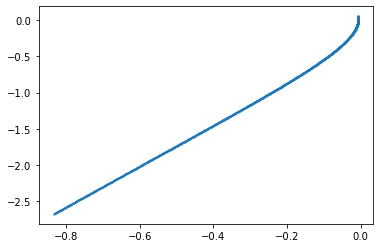

In [ ]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer1.zero_grad()
 
    net1_randpts = randpts

    V_field = net1(net1_randpts)
    net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())  # Directly use .item() for scalar value

    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}') 
            if L1.item() < 0.02  * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
    if i % 2000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        # x2 = x1
        vals1= []
        for _ in range(int(1e3)):

            V_field = net1(x1)
            x1 = x1 + V_field*dt
                
            vals1.append(x1.detach().numpy().flatten()) 
        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
        plt.show()

In [ ]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):


    V_field = net1(x1)
    x1 = x1 + V_field*dt
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
plt.show()

In [ ]:
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []
net2_randpts = randpts.clone()  

V_field2 = net2(net2_randpts)
net2_randpts = net2_randpts+dt* V_field2
U_net = Ulam(randpts,net2_randpts)
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

In [ ]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()

    net2_randpts = randpts

    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts+dt*V_field2

    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L2.item()}')
            if L2.item() < 0.02  * initial_L2:
                print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
                break
        
    # Visualization
    if i % 2000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        vals2 = []
        for _ in range(int(1e3)):

            V_field2 = net2(x2)
            x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        plt.show()

In [ ]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    V_field2 = net2(x2)
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
plt.show()
# plt.plot(vals2[:, 0][:100])
# plt.show()

In [ ]:
#SINDy
sindy_model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree= 5))
sindy_model.fit(randpts, t=sampling_time * dt)



In [ ]:
x0 = [randpts[:, 0][0], randpts[:, 1][0],randpts[:, 2][0],randpts[:, 3][0],randpts[:, 4][0]]  # Initial values from the data
vals_sindy = [x0]  # To store the trajectory

# Manual Euler integration
x = np.array(x0)
try:
    for _ in range(simulation_t):  
        try:
            x = x + dt * sindy_model.predict(np.array(x).reshape(1, -1)).flatten()
        except ValueError as e:
            print(f"ValueError occurred: {e}")
            raise  
        vals_sindy.append(x)
except ValueError:
    print(f"Stopped simulation at outer iteration {_} due to an error.")

vals_sindy = np.array(vals_sindy)

In [ ]:

plt.scatter(vals_sindy[:,0][:-3],vals_sindy[:,1][:-3],s = 1)

In [ ]:


GT = scipy.integrate.odeint(L96, M_scale*randpts[0], np.arange(0.0, simulation_t*dt, dt))

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 1], linewidth=0.6)
axes[1].set_title('Ours')

axes[3].plot(M_scale * vals_sindy[:, 0][:-3], M_scale * vals_sindy[:, 1][:-3], linewidth=1)
axes[3].set_title('SINDy')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 1], linewidth=0.6)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 1], label="Ground Truth", linewidth=0.6, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 1], s=1, c="tomato", alpha = 0.5,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_aspect('equal')

fig.text(0.04, 0.5, 'Lorenz-96', va='center', rotation='vertical', fontsize=14)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()